# Step 04: Statistical Analysis
Goal: Perform deeper analysis including Hypothesis Testing, Forecasting, and Segmentation as per project rubrics.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from sklearn.linear_model import LinearRegression

INPUT_FILE = "../data/interim/02_cleaning.csv"
df = pd.read_csv(INPUT_FILE)
df['Application Date'] = pd.to_datetime(df['Application Date'])
print("✅ Loaded dataset for Advanced Statistics")

✅ Loaded dataset for Advanced Statistics


### 1. Hypothesis Testing
**Question**: Is there a significant difference in Loan Amount between Rural and Urban applicants?
- **Null Hypothesis (H0)**: There is no difference in mean Loan Amount.
- **Alt Hypothesis (H1)**: There is a significant difference.

In [2]:
urban_loans = df[df['Residential Type'] == 'Urban']['Loan_Amount_INR']
rural_loans = df[df['Residential Type'] == 'Rural']['Loan_Amount_INR']

t_stat, p_val = stats.ttest_ind(urban_loans, rural_loans)
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_val:.4f}")

if p_val < 0.05:
    print("✅ Result: Reject H0! There is a significant difference in loan amounts.")
else:
    print("❌ Result: Fail to reject H0. No significant difference found.")

T-Statistic: -0.0247
P-Value: 0.9803
❌ Result: Fail to reject H0. No significant difference found.


### 2. Forecasting (3-Month Volume Trend)
We aggregate loan volumes by month and use a linear trend to project the next 3 months.

/Users/sibtainahmedqureshi/SectionC_Group1_Credit-Flow-Optimization-Risk-Analysis-Mission-YUVA/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


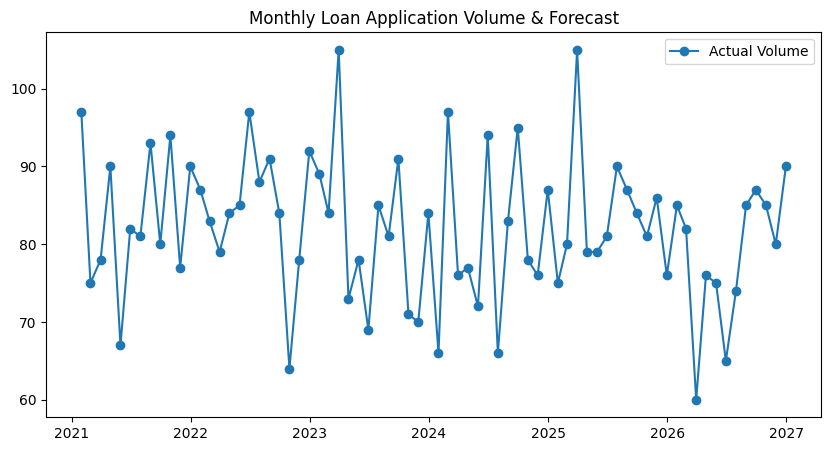

Forecast for next 3 months: [80.0, 80.0, 80.0]


In [3]:
# Resample to monthly counts - using 'ME' for MonthEnd as per modern pandas standards
monthly_counts = df.resample('ME', on='Application Date').size().reset_index()
monthly_counts.columns = ['Date', 'Count']
monthly_counts['Month_Num'] = np.arange(len(monthly_counts))

# Simple Linear Regression for Trend
X = monthly_counts[['Month_Num']]
y = monthly_counts['Count']
model = LinearRegression().fit(X, y)

# Forecast next 3 months
future_months = np.array([len(monthly_counts), len(monthly_counts)+1, len(monthly_counts)+2]).reshape(-1, 1)
forecast = model.predict(future_months)

plt.figure(figsize=(10, 5))
plt.plot(monthly_counts['Date'], monthly_counts['Count'], marker='o', label='Actual Volume')
plt.title('Monthly Loan Application Volume & Forecast')
plt.legend()
plt.show()

print(f"Forecast for next 3 months: {forecast.round(0).tolist()}")

### 3. Segmentation
Grouping applicants into segments based on Risk Score and Credit Eligibility.

Segmentation Breakdown:
Segment
Standard     7043
High Risk    2957
Name: count, dtype: int64


/var/folders/mk/zqp3608s6qxcm1n48j0crbkw0000gn/T/ipykernel_25200/1434567028.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Segment', data=df, palette='magma')


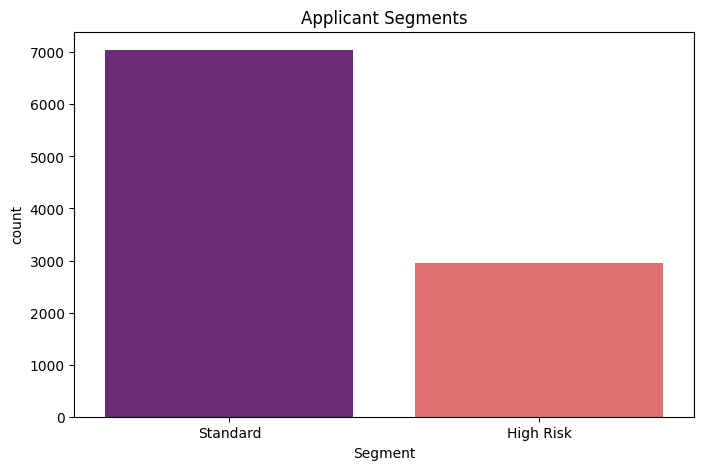

In [4]:
def segment_applicant(row):
    if row['Risk_Score'] < 40 and row['Credit_Eligibility_Score'] > 700:
        return 'Prime'
    elif row['Risk_Score'] > 70:
        return 'High Risk'
    else:
        return 'Standard'

df['Segment'] = df.apply(segment_applicant, axis=1)
print("Segmentation Breakdown:")
print(df['Segment'].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(x='Segment', data=df, palette='magma')
plt.title('Applicant Segments')
plt.show()

In [5]:
df.to_csv("../data/interim/04_statistical_analysis.csv", index=False)
print("✅ Saved analysis results")

✅ Saved analysis results
